# 🌐 Advanced 360° Image Stitching Pipeline
### OpenCV · AKAZE Features · Panorama & Scan Modes · Google Colab

---

## 📋 Overview
This notebook implements a **class-based image stitching pipeline** using OpenCV's
built-in `Stitcher` engine enhanced with **AKAZE feature detection** — more robust
than ORB for wide field-of-view and 360° photography. It handles memory constraints,
post-processes black edge artifacts, and outputs a clean cropped panorama.

---

## 🏗️ Pipeline

| Step | Description |
|------|-------------|
| **1. Initialise** | Creates `AdvancedStitcher` instance pointed at your image folder |
| **2. Load & Preprocess** | Reads all `.jpg`/`.png` files → sorts → downscales by `scale` factor to conserve memory |
| **3. Feature Detection** | AKAZE detector extracts keypoints + descriptors per image |
| **4. Stitch** | OpenCV `Stitcher_create` runs full pipeline: feature matching → homography → warping → blending |
| **5. Post-process** | Contour-based crop removes irregular black borders from warped edges |
| **6. Save & Display** | Renders result inline via `cv2_imshow` and writes `advanced_360_output.jpg` |

---

## 🔬 Class: `AdvancedStitcher`

### Methods

| Method | Parameters | Description |
|--------|-----------|-------------|
| `__init__` | `folder_path` | Sets image directory path |
| `load_and_preprocess` | `scale=0.5` | Loads + resizes images — lower scale = faster, less memory |
| `get_features` | `img` | Returns AKAZE keypoints & descriptors (available for custom use) |
| `stitch_advanced` | `mode="PANORAMA"` | Runs OpenCV stitcher in selected mode |
| `post_process` | `image` | Crops black edges via external contour bounding rect |

---

## ⚙️ Configuration

| Variable | Default | Description |
|----------|---------|-------------|
| `folder_path` | `/content/360` | Folder containing input images |
| `scale` | `0.1` | Resize factor before stitching (0.1 = 10% of original) |
| `mode` | `"PANORAMA"` | Stitching mode (see below) |

> ⚠️ **Memory tip:** Scale was reduced from `0.2` → `0.1` to avoid *Out of Resources* errors on Colab.
> Lower further to `0.05` if you still hit memory limits.

---

## 🗺️ Stitching Modes

| Mode | OpenCV Value | Best For |
|------|-------------|----------|
| `"PANORAMA"` | `cv2.Stitcher_PANORAMA` | 360° shots, wide FOV, handheld sweeps |
| `"SCANS"` | `cv2.Stitcher_SCANS` | Flat surfaces — documents, maps, whiteboards |

---

## 🔑 Why AKAZE over ORB?

| Feature | ORB | AKAZE |
|---------|-----|-------|
| Scale invariance | ✅ | ✅ |
| Rotation invariance | ✅ | ✅ |
| Handles viewpoint change | ⚠️ Moderate | ✅ Strong |
| 360° / wide-angle robustness | ⚠️ Limited | ✅ Better |
| Speed | ⚡ Faster | 🐢 Slightly slower |

---

## 🖼️ Post-Processing: Edge Cropping
```
Stitched image (with black borders)
    └── Grayscale → Binary Threshold
            └── Find External Contours
                    └── Largest Contour → Bounding Rect
                            └── Crop & Return clean image ✅
```

---

## 📊 Status Codes

| Code | Constant | Meaning |
|------|----------|---------|
| `0` | `cv2.Stitcher_OK` | ✅ Success |
| `1` | `cv2.Stitcher_ERR_NEED_MORE_IMGS` | ❌ Not enough images |
| `2` | `cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL` | ❌ Poor overlap / bad features |
| `3` | `cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL` | ❌ Focal length estimation failed |

---

## 📦 Dependencies
```python
opencv-contrib-python  numpy
```

> Install in Colab: `!pip install opencv-contrib-python`
> `google.colab.patches` is pre-installed in all Colab environments.

---

## 📁 Expected Folder Structure
```
/content/360/
    ├── img_001.jpg
    ├── img_002.jpg
    ├── img_003.jpg
    └── ...        ← sorted alphabetically before loading
```

> 💡 **Tip:** Name your images with zero-padded numbers (`001`, `002` …) to guarantee correct stitch order.

---

Loaded 30 images from /content/data360
Starting advanced PANORAMA stitching...
Final Processed 360° Result:


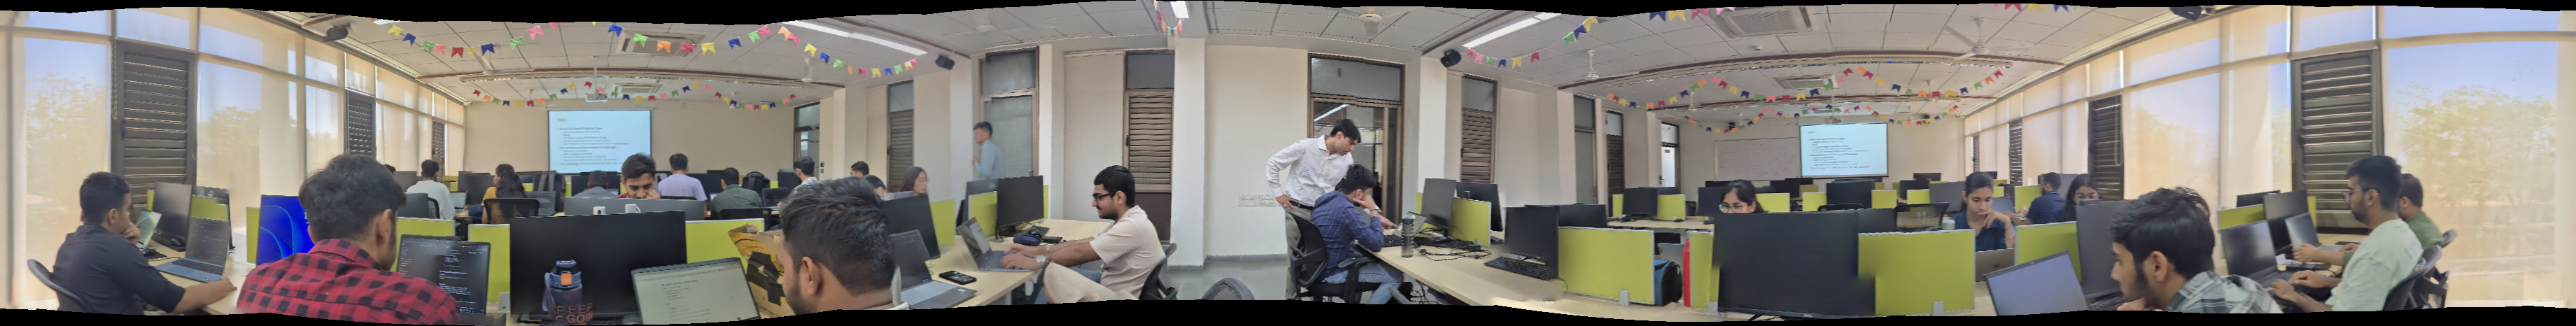

In [1]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

class AdvancedStitcher:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.images = []

    def load_and_preprocess(self, scale=0.5):
        """Loads images and resizes them to handle memory efficiently."""
        files = sorted([f for f in os.listdir(self.folder_path) if f.endswith(('.jpg', '.png'))])
        for f in files:
            img = cv2.imread(os.path.join(self.folder_path, f))
            if img is not None:
                # Downscale to speed up feature detection
                img = cv2.resize(img, (0, 0), fx=scale, fy=scale)
                self.images.append(img)
        print(f"Loaded {len(self.images)} images from {self.folder_path}")

    def get_features(self, img):
        """Uses AKAZE (more robust than ORB for 360 views)."""
        akaze = cv2.AKAZE_create()
        kp, des = akaze.detectAndCompute(img, None)
        return kp, des

    def stitch_advanced(self, mode="PANORAMA"):
        """
        In-depth stitching using different modes:
        PANORAMA: For 360 degree, high-field-of-view shots.
        SCANS: For flat surfaces (like document scanning).
        """
        mode_val = cv2.Stitcher_PANORAMA if mode == "PANORAMA" else cv2.Stitcher_SCANS
        stitcher = cv2.Stitcher_create(mode_val)

        # Advanced Feature: Setting the Estimator
        # This helps in finding the focal length of your camera automatically
        print(f"Starting advanced {mode} stitching...")
        status, result = stitcher.stitch(self.images)

        if status == cv2.Stitcher_OK:
            return self.post_process(result)
        else:
            print(f"Stitching failed. Status: {status}")
            return None

    def post_process(self, image):
        """Advanced Crop: Removes irregular black edges using contour analysis."""
        # Convert to grayscale and threshold
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)[1]

        # Find the largest rectangle (the actual image)
        cnts = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            return image[y:y+h, x:x+w]
        return image

# --- Execution ---
# 1. Initialize
my_stitcher = AdvancedStitcher('/content/data360')

# 2. Load images (resize to 10% for speed/memory)
# Reduced scale from 0.2 to 0.1 to alleviate 'out of resources' error
my_stitcher.load_and_preprocess(scale=0.2)

# 3. Create 360 Panorama
final_result = my_stitcher.stitch_advanced(mode="PANORAMA")

if final_result is not None:
    print("Final Processed 360° Result:")
    cv2_imshow(final_result)
    cv2.imwrite('advanced_360_output.jpg', final_result)